# Volatility, HMM Regimes, Hawkes Events, and Option-IV Indicators

This notebook applies volatility and regime techniques to the London Strategic Edge daily OHLCV data saved in `data/lse_market_data/combined_1d.parquet`, and optionally enriches Nasdaq/Brazil ADR names with LSE option-chain implied volatility and Greeks.

## Research And Implementation Notes

- Implied volatility surfaces are summarized with ATM IV, IV term slope, downside/upside skew, IV dispersion, gamma-volume proxy, vega-volume proxy, and IV-minus-realized-volatility spreads.
- Range-volatility indicators use close-to-close realized vol plus Parkinson, Garman-Klass, Rogers-Satchell, and Yang-Zhang style OHLC estimators.
- HMM regimes are fit with Gaussian emissions using standardized return, volatility, ATR, volume, and drawdown features.
- Hawkes is applied as an event-clustering model on detected daily jump/high-volatility events. With daily candles this is a lower-frequency proxy, not a replacement for true tick/order-book Hawkes modeling.

Primary references checked:

- Hawkes processes in finance: https://arxiv.org/abs/1502.04592
- `tick.hawkes` docs for Hawkes inference patterns: https://x-datainitiative.github.io/tick/modules/hawkes.html
- `hmmlearn` HMM documentation: https://hmmlearn.readthedocs.io/en/latest/tutorial.html
- SciPy `minimize` documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
- scikit-learn `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- Parkinson volatility estimator reference: https://ideas.repec.org/a/ucp/jnlbus/v53y1980i1p61-65.html
- Yang-Zhang estimator reference: https://econpapers.repec.org/RePEc%3Aucp%3Ajnlbus%3Av%3A73%3Ay%3A2000%3Ai%3A3%3Ap%3A477-91

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from features.volatility_regime_indicators import (
    RegimeAnalysisConfig,
    compute_market_indicators,
    fetch_lse_options,
    fit_hawkes_for_symbols,
    fit_hmm_regimes,
    load_market_data,
    save_outputs,
    summarize_option_indicators,
)

plt.rcParams["figure.dpi"] = 130
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print("Imports OK")

Imports OK


In [2]:
cfg = RegimeAnalysisConfig()
cfg.output_dir.mkdir(parents=True, exist_ok=True)
fig_dir = Path("images/volatility_regime_analysis")
fig_dir.mkdir(parents=True, exist_ok=True)

print(cfg)
print(f"Output dir: {cfg.output_dir}")
print(f"Figure dir: {fig_dir}")

RegimeAnalysisConfig(input_path=PosixPath('data/lse_market_data/combined_1d.parquet'), output_dir=PosixPath('data/volatility_regime_analysis'), annualization_crypto=365, annualization_trading=252, windows=(10, 20, 60), hmm_components=3, min_hmm_rows=120, event_window=60, event_z_threshold=2.25, event_abs_return_quantile=0.9, hawkes_beta_default=0.05, max_hawkes_symbols=44, selected_symbols=('BTC/USD', 'ETH/USD', 'AAPL', 'NVDA', 'PBR', 'VALE'), option_underlyings=('AAPL', 'NVDA', 'TSLA', 'MSFT', 'PBR', 'VALE'), option_min_dte=7, option_max_dte=180, option_limit=5000)
Output dir: data/volatility_regime_analysis
Figure dir: images/volatility_regime_analysis


In [3]:
raw = load_market_data(cfg.input_path)
print(f"Rows: {len(raw):,}")
print(f"Symbols: {raw['symbol'].nunique():,}")
print(f"Date range: {raw['timestamp'].min()} -> {raw['timestamp'].max()}")
display(raw.groupby('asset_group').size().rename('rows').reset_index())
display(raw.head())

Rows: 12,577
Symbols: 44
Date range: 2025-01-01 00:00:00+00:00 -> 2026-07-11 00:00:00+00:00


,asset_group,rows
0,b3,1635
1,crypto,5237
2,nasdaq,5705


,asset_group,symbol,open,high,low,close,volume,timestamp
0,nasdaq,AAPL,250.45,250.45,250.41,250.42,3384.0,2025-01-01 00:00:00+00:00
1,nasdaq,AAPL,251.90,251.97,241.83,243.24,33523244.0,2025-01-02 00:00:00+00:00
2,nasdaq,AAPL,243.24,244.66,241.89,243.24,25470622.0,2025-01-03 00:00:00+00:00
3,nasdaq,AAPL,243.45,247.33,243.14,244.72,32248062.0,2025-01-06 00:00:00+00:00
4,nasdaq,AAPL,244.80,245.54,241.28,242.15,28206428.0,2025-01-07 00:00:00+00:00


In [4]:
indicators = compute_market_indicators(raw, cfg)
print(f"Indicator rows: {len(indicators):,}")
print(f"Indicator columns: {len(indicators.columns):,}")

latest_indicators = (
    indicators.sort_values('timestamp')
    .groupby(['asset_group', 'symbol'])
    .tail(1)
    .sort_values(['asset_group', 'rv_yang_zhang_20'], ascending=[True, False])
)

cols = ['asset_group', 'symbol', 'timestamp', 'close', 'rv_close_20', 'rv_parkinson_20', 'rv_yang_zhang_20', 'atr_pct_14', 'rsi_14', 'drawdown_60', 'event_flag']
display(latest_indicators[cols].head(25))

Indicator rows: 12,577
Indicator columns: 46


,asset_group,symbol,timestamp,close,rv_close_20,rv_parkinson_20,rv_yang_zhang_20,atr_pct_14,rsi_14,drawdown_60,event_flag
12035,b3,VIV,2026-07-10 00:00:00+00:00,13.94000,0.486034,0.796014,1.164487,0.064009,56.166549,-0.139506,0
10847,b3,SID,2026-07-10 00:00:00+00:00,1.01000,0.680188,0.639271,0.894656,0.069091,43.514680,-0.293706,0
11454,b3,SUZ,2026-07-10 00:00:00+00:00,8.10000,0.296095,0.656037,0.805948,0.054690,49.380474,-0.109890,0
11504,b3,TIMB,2026-07-10 00:00:00+00:00,22.28000,0.415080,0.410173,0.652158,0.037042,50.358423,-0.156699,0
11935,b3,UGP,2026-07-10 00:00:00+00:00,6.00000,0.374562,0.567198,0.638655,0.049254,73.164046,-0.018003,0
4569,b3,CSAN,2026-07-10 00:00:00+00:00,3.15000,0.418471,0.519919,0.618729,0.054074,61.016313,-0.262295,0
9487,b3,NU,2026-07-10 00:00:00+00:00,13.79000,0.437882,0.465378,0.539821,0.050592,59.070426,-0.106865,0
6640,b3,GGB,2026-07-10 00:00:00+00:00,4.50000,0.425518,0.336070,0.529347,0.036636,55.436744,-0.089069,0
10801,b3,SBS,2026-07-10 00:00:00+00:00,6.13000,0.318906,0.446637,0.515718,0.040013,63.724815,-0.102489,1
12081,b3,XP,2026-07-10 00:00:00+00:00,16.91000,0.403601,0.398953,0.423185,0.046737,54.194456,-0.137245,0


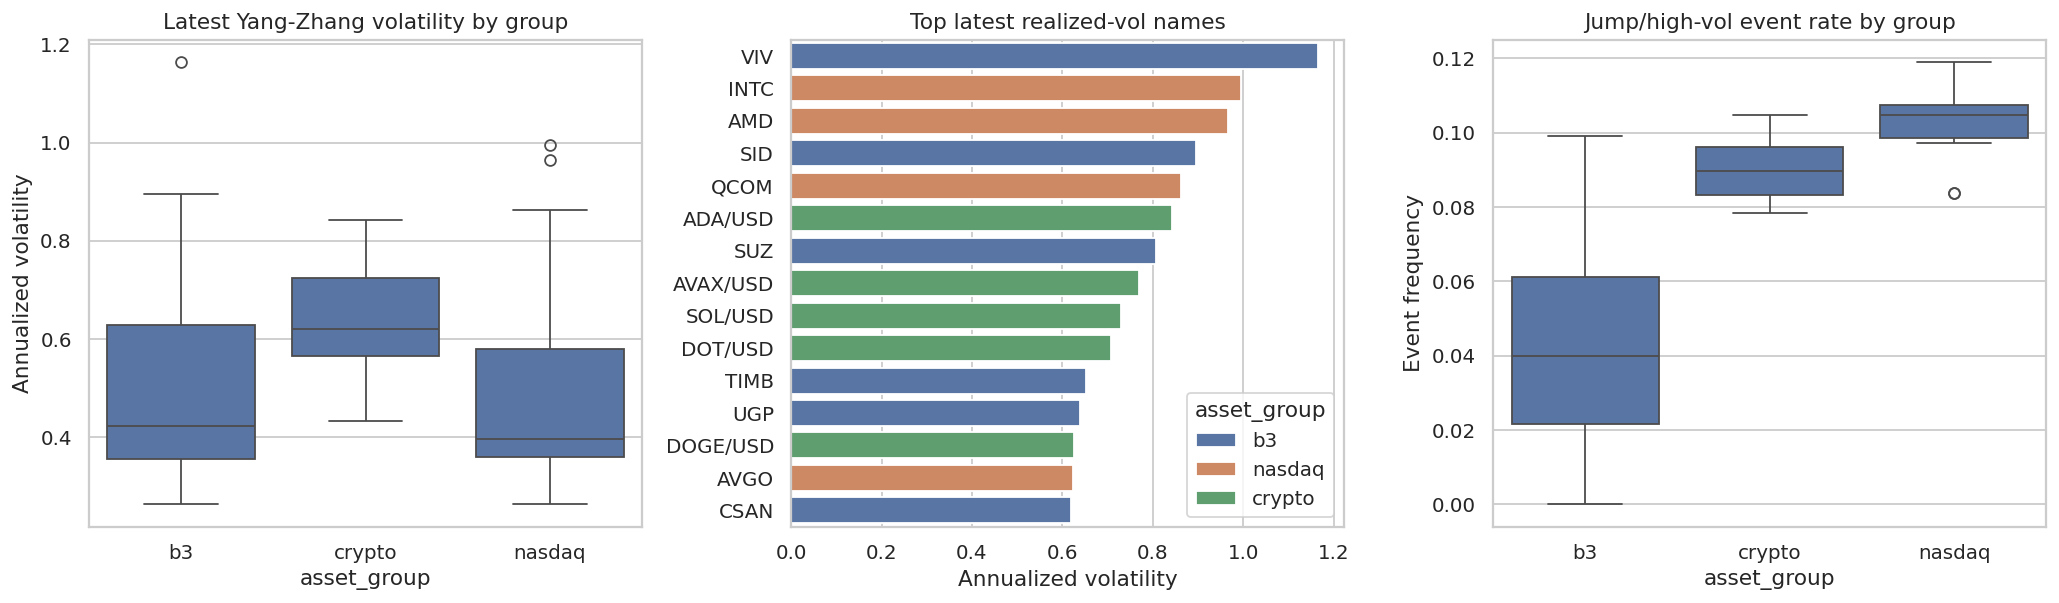

Saved: images/volatility_regime_analysis/volatility_indicator_summary.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_df = latest_indicators.dropna(subset=['rv_yang_zhang_20']).copy()
sns.boxplot(data=plot_df, x='asset_group', y='rv_yang_zhang_20', ax=axes[0])
axes[0].set_title('Latest Yang-Zhang volatility by group')
axes[0].set_ylabel('Annualized volatility')

top_vol = plot_df.nlargest(15, 'rv_yang_zhang_20')
sns.barplot(data=top_vol, y='symbol', x='rv_yang_zhang_20', hue='asset_group', dodge=False, ax=axes[1])
axes[1].set_title('Top latest realized-vol names')
axes[1].set_xlabel('Annualized volatility')
axes[1].set_ylabel('')

event_rates = indicators.groupby(['asset_group', 'symbol'])['event_flag'].mean().reset_index()
sns.boxplot(data=event_rates, x='asset_group', y='event_flag', ax=axes[2])
axes[2].set_title('Jump/high-vol event rate by group')
axes[2].set_ylabel('Event frequency')

fig.tight_layout()
vol_summary_path = fig_dir / 'volatility_indicator_summary.png'
fig.savefig(vol_summary_path, dpi=160, bbox_inches='tight')
plt.show()
print(f"Saved: {vol_summary_path}")

In [6]:
hmm_regimes, hmm_summary = fit_hmm_regimes(indicators, cfg)
print(f"HMM regime rows: {len(hmm_regimes):,}")
print(f"HMM summary rows: {len(hmm_summary):,}")
display(hmm_summary.sort_values(['symbol', 'hmm_state_rank' if 'hmm_state_rank' in hmm_summary.columns else 'hmm_regime']).head(20))

if not hmm_regimes.empty:
    regime_counts = hmm_regimes.groupby(['asset_group', 'hmm_regime']).size().rename('rows').reset_index()
    display(regime_counts)

HMM regime rows: 11,400
HMM summary rows: 81


,asset_group,symbol,hmm_state_raw,hmm_regime,mean_return,mean_vol,mean_drawdown,rows,converged,log_likelihood
1,nasdaq,AAPL,1,calm,0.001197,0.251315,-0.053787,320,True,-1675.851053
2,nasdaq,AAPL,2,neutral,-0.017734,0.722221,-0.199589,29,True,-1675.851053
0,nasdaq,AAPL,0,stress,0.022316,2.298287,-0.022800,20,True,-1675.851053
4,crypto,ADA/USD,1,calm,-0.002891,0.570379,-0.223843,174,True,-2389.871246
3,crypto,ADA/USD,0,neutral,-0.003182,0.808134,-0.311631,260,True,-2389.871246
5,crypto,ADA/USD,2,stress,-0.004193,1.847302,-0.275005,51,True,-2389.871246
8,nasdaq,ADBE,2,calm,-0.001343,0.250369,-0.088115,223,True,-2068.283146
7,nasdaq,ADBE,1,neutral,0.000895,0.412458,-0.199258,87,True,-2068.283146
6,nasdaq,ADBE,0,stress,-0.007493,0.509854,-0.226788,58,True,-2068.283146
10,nasdaq,AMD,1,calm,0.003451,0.421857,-0.103446,145,True,-2008.932952


,asset_group,hmm_regime,rows
0,b3,calm,385
1,b3,neutral,180
2,b3,stress,218
3,crypto,calm,1623
4,crypto,neutral,2010
5,crypto,stress,1474
6,nasdaq,calm,2541
7,nasdaq,neutral,1962
8,nasdaq,stress,1007


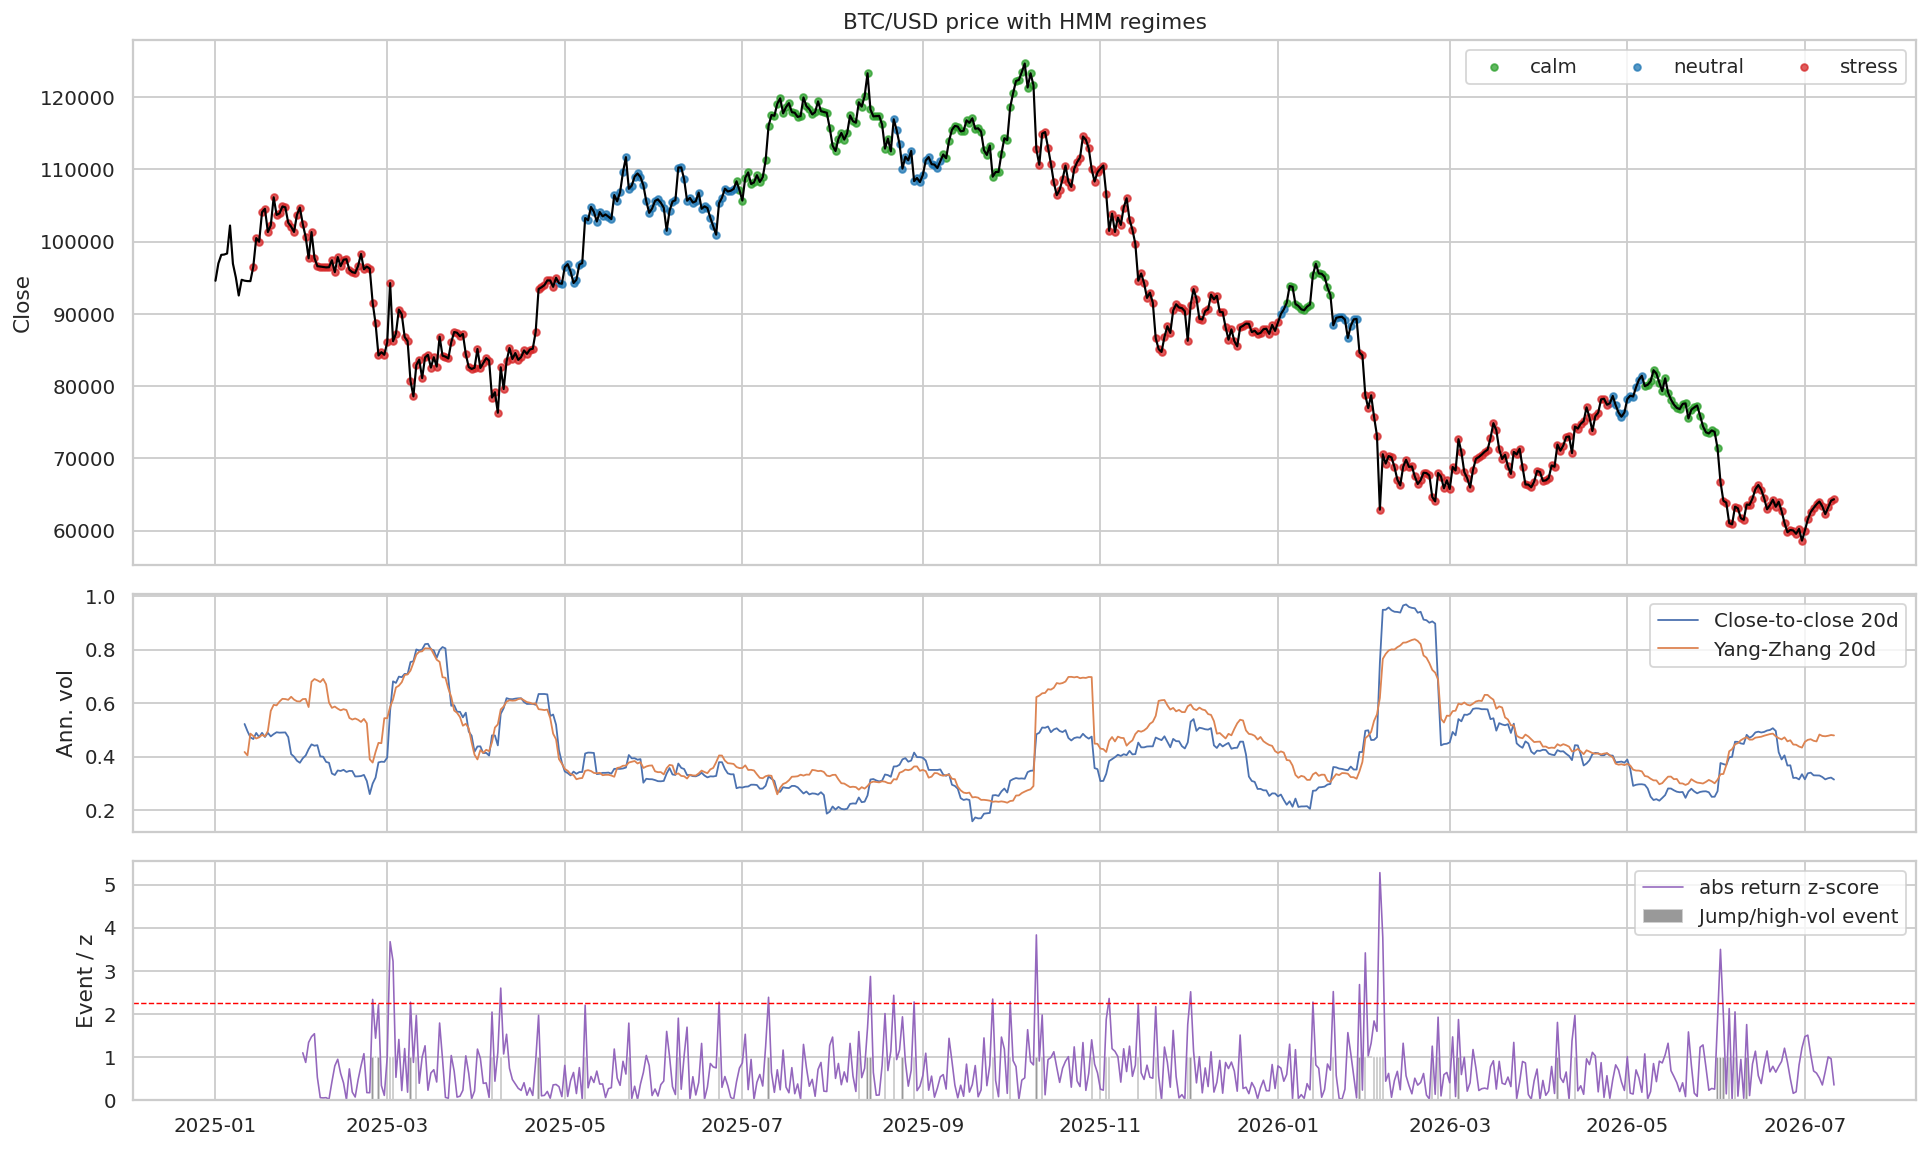

Saved: images/volatility_regime_analysis/BTC-USD_hmm_dashboard.png


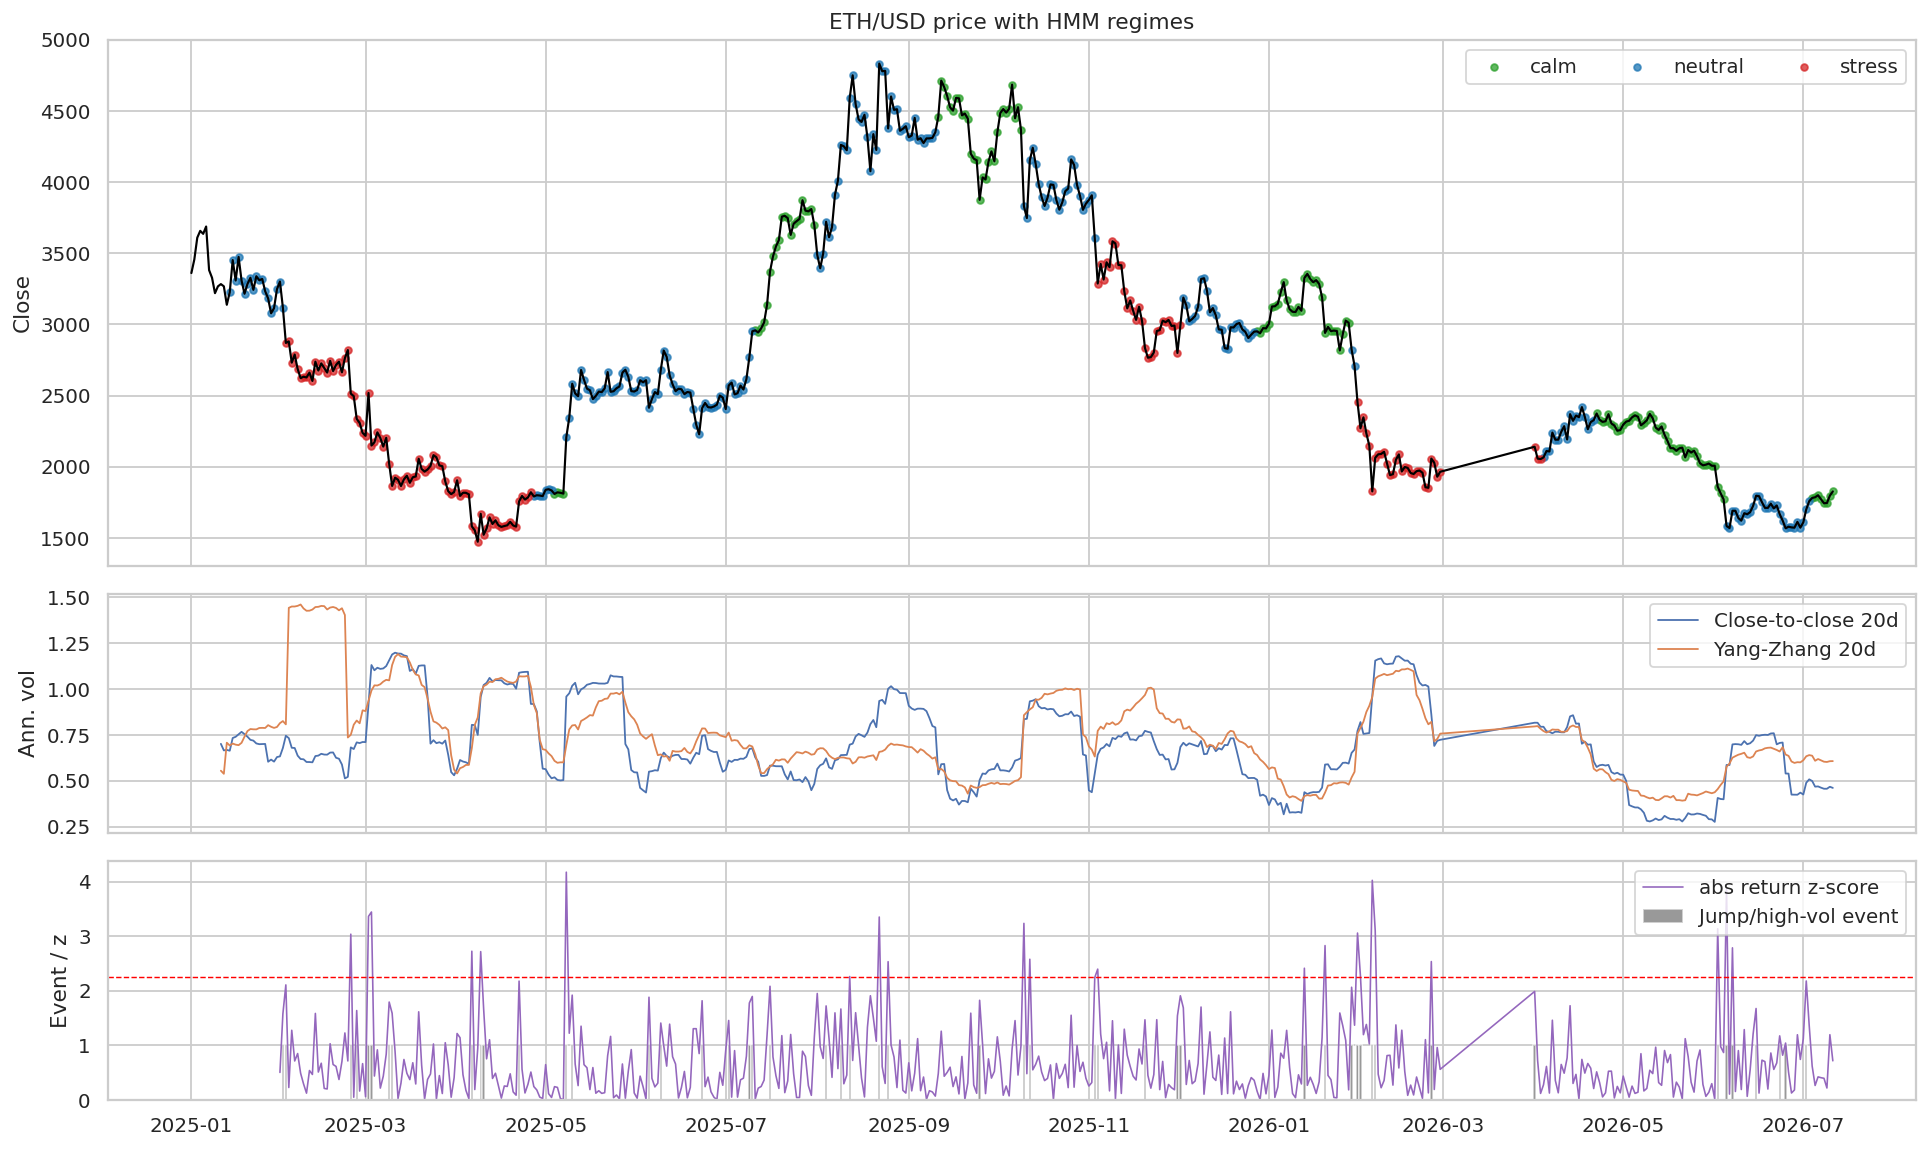

Saved: images/volatility_regime_analysis/ETH-USD_hmm_dashboard.png


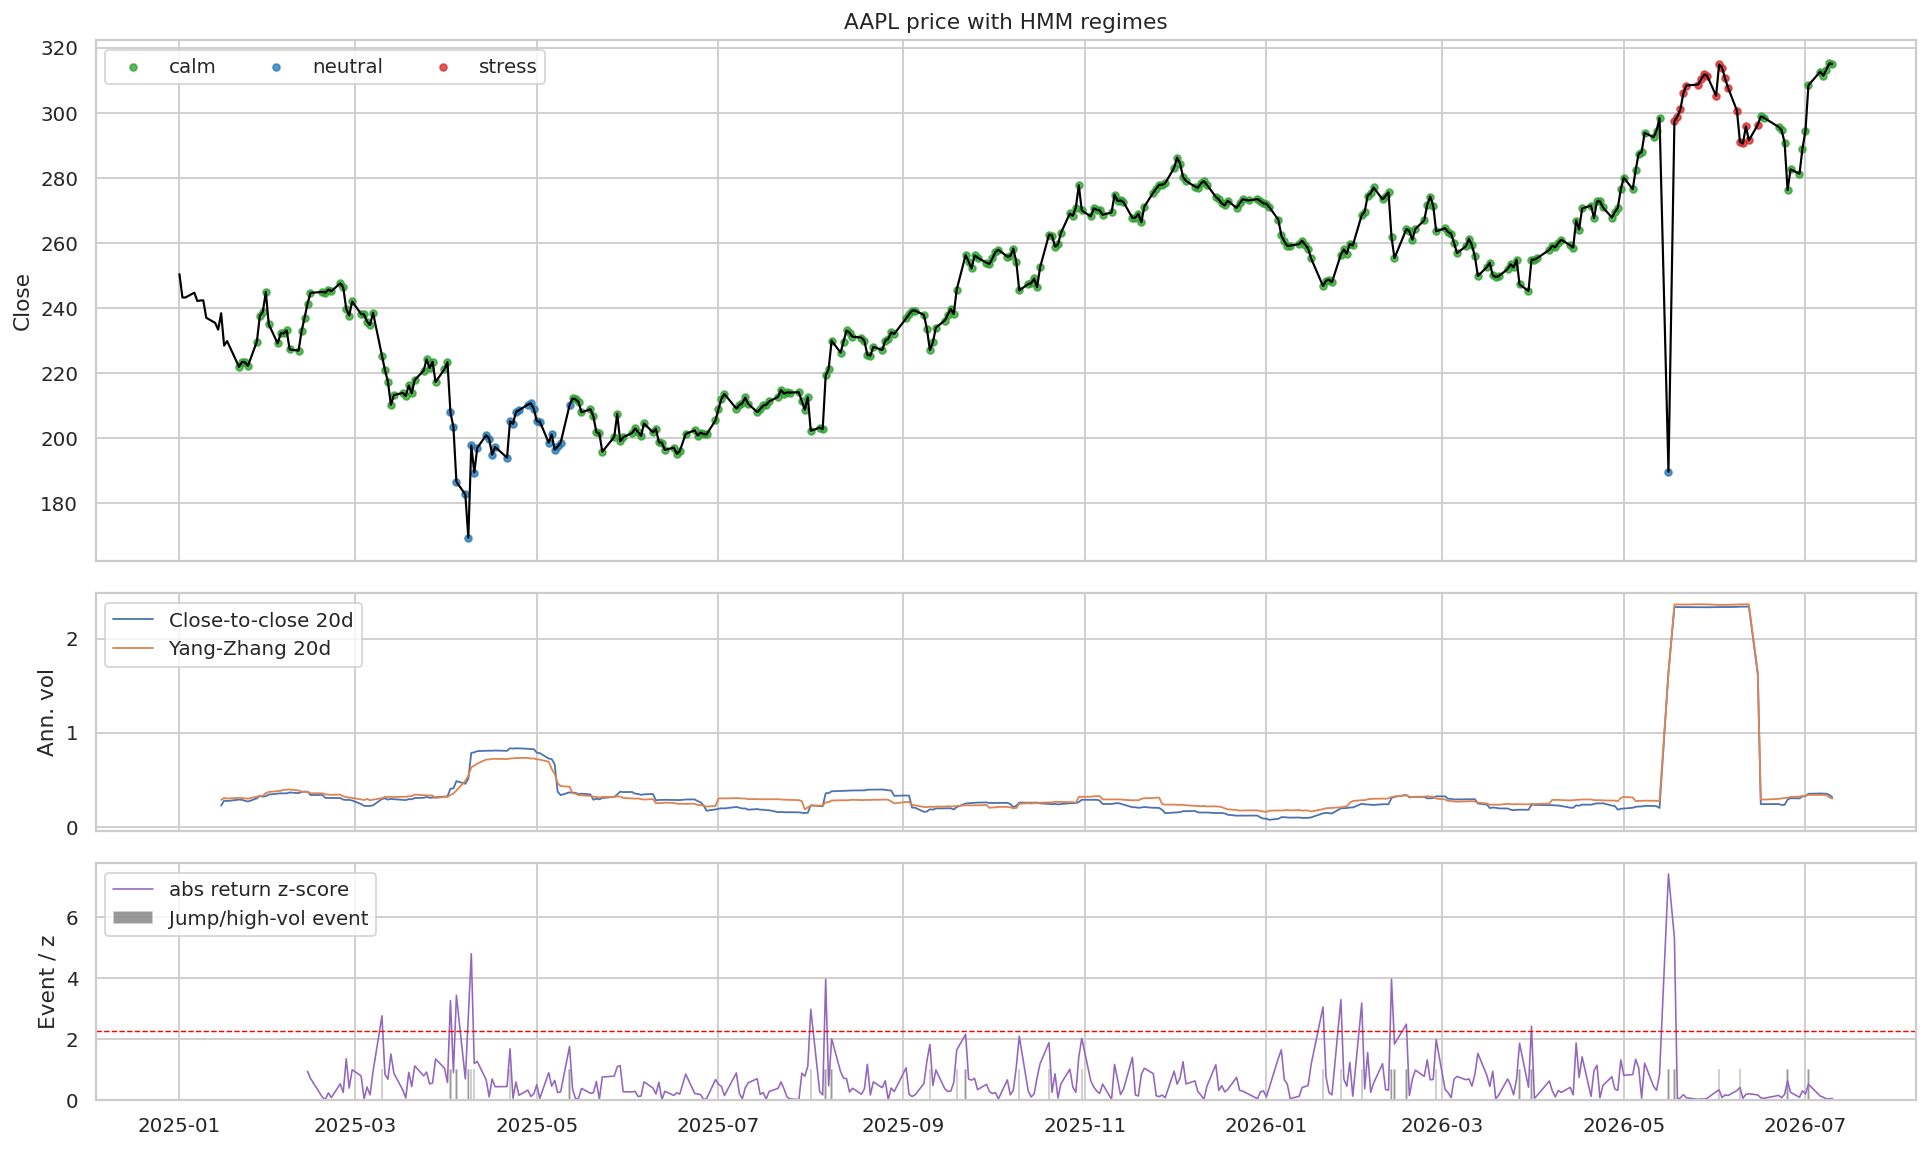

Saved: images/volatility_regime_analysis/AAPL_hmm_dashboard.png


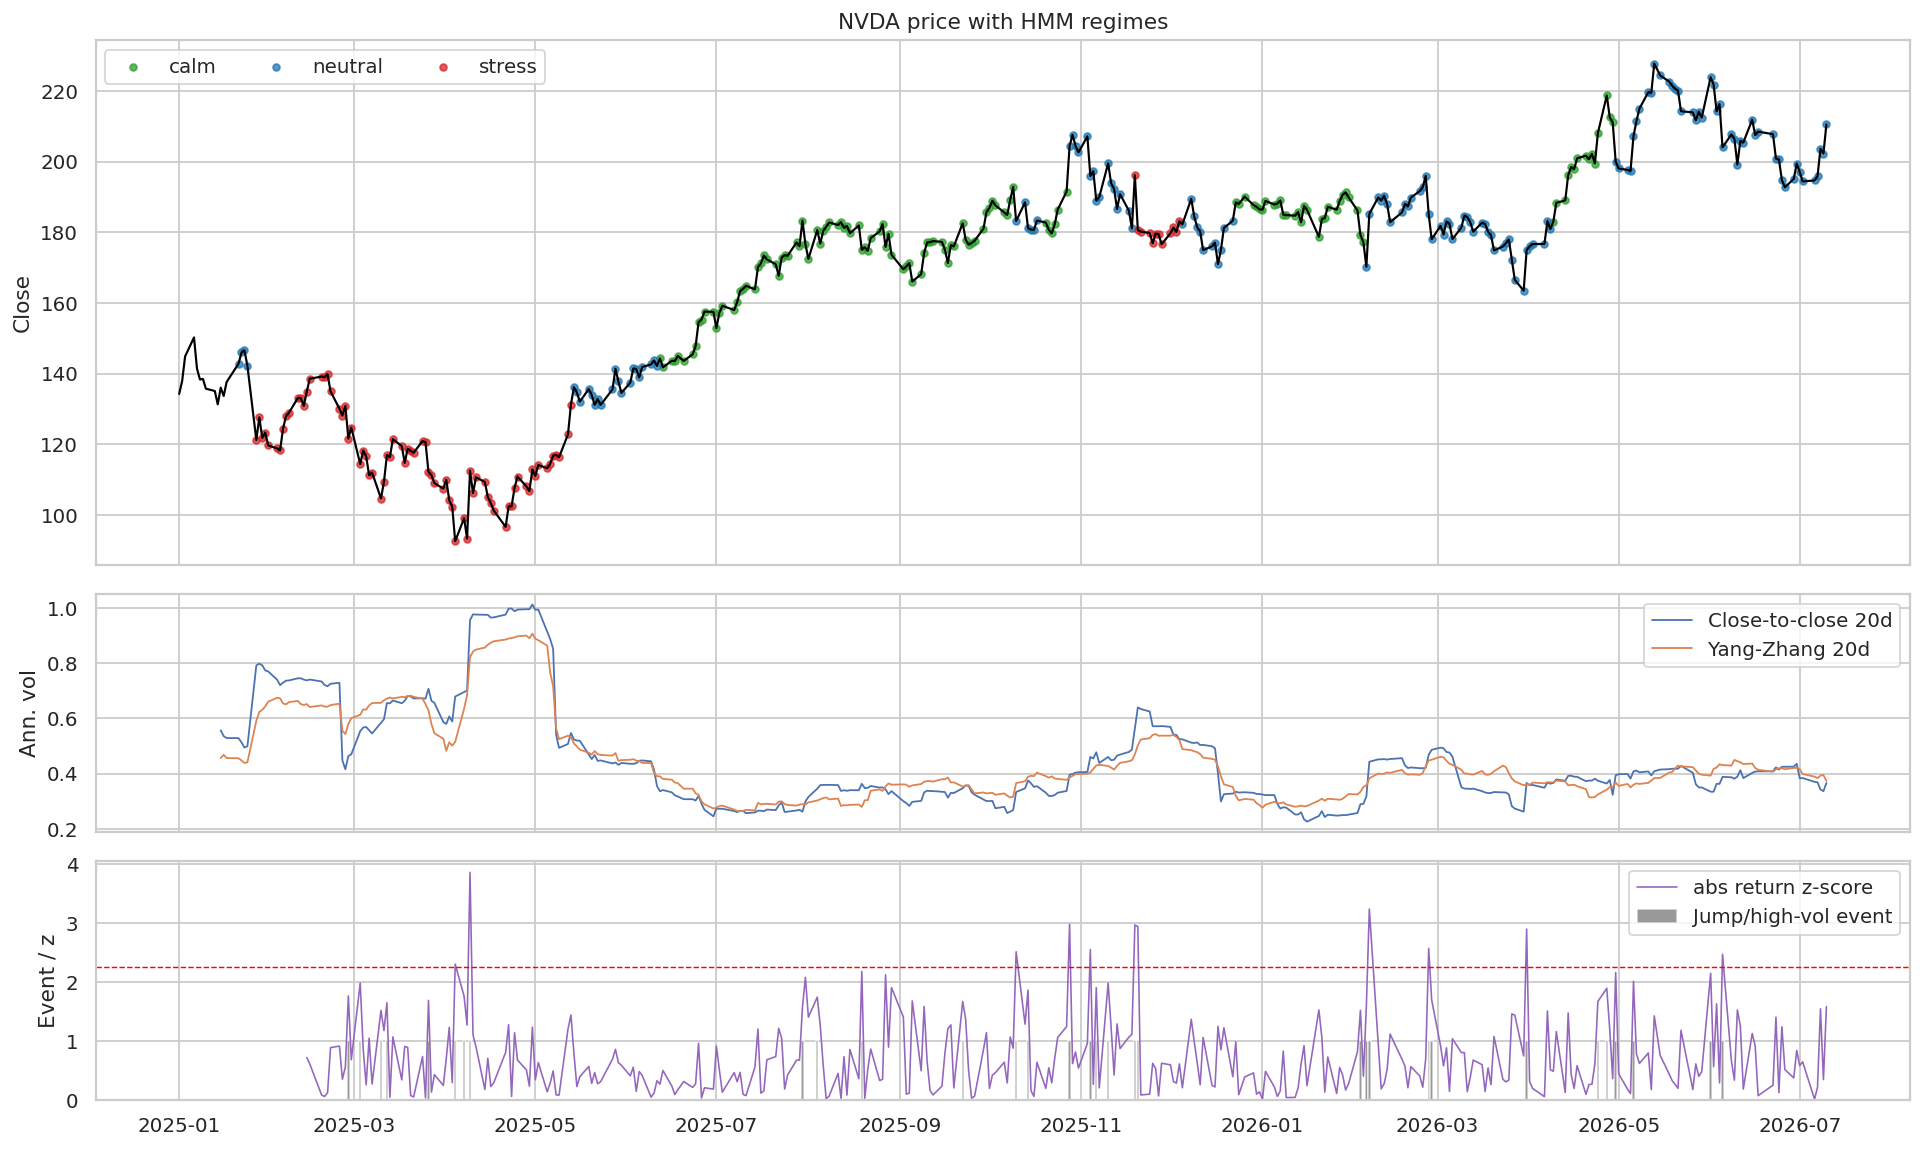

Saved: images/volatility_regime_analysis/NVDA_hmm_dashboard.png


In [7]:
def plot_symbol_hmm(symbol: str):
    px = indicators[indicators['symbol'] == symbol].sort_values('timestamp')
    rg = hmm_regimes[hmm_regimes['symbol'] == symbol].sort_values('timestamp')
    if px.empty or rg.empty:
        print(f"No HMM output for {symbol}")
        return None
    merged = px.merge(rg[['timestamp', 'hmm_regime', 'hmm_state_rank']], on='timestamp', how='left')
    colors = {'calm': '#2ca02c', 'neutral': '#1f77b4', 'stress': '#d62728', 'extreme': '#7f0000'}
    fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True, gridspec_kw={'height_ratios': [2.2, 1, 1]})
    axes[0].plot(merged['timestamp'], merged['close'], color='black', lw=1.2)
    for regime, sub in merged.dropna(subset=['hmm_regime']).groupby('hmm_regime'):
        axes[0].scatter(sub['timestamp'], sub['close'], s=14, color=colors.get(regime, 'gray'), label=regime, alpha=0.75)
    axes[0].set_title(f'{symbol} price with HMM regimes')
    axes[0].legend(loc='best', ncol=4)
    axes[0].set_ylabel('Close')

    axes[1].plot(merged['timestamp'], merged['rv_close_20'], label='Close-to-close 20d', lw=1)
    axes[1].plot(merged['timestamp'], merged['rv_yang_zhang_20'], label='Yang-Zhang 20d', lw=1)
    axes[1].set_ylabel('Ann. vol')
    axes[1].legend(loc='best')

    axes[2].bar(merged['timestamp'], merged['event_flag'], color='#555555', alpha=0.6, label='Jump/high-vol event')
    axes[2].plot(merged['timestamp'], merged['return_z_60'].abs(), color='#9467bd', lw=0.9, label='abs return z-score')
    axes[2].axhline(cfg.event_z_threshold, color='red', ls='--', lw=0.8)
    axes[2].set_ylabel('Event / z')
    axes[2].legend(loc='best')
    fig.tight_layout()
    path = fig_dir / f'{symbol.replace("/", "-")}_hmm_dashboard.png'
    fig.savefig(path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")
    return path

for symbol in cfg.selected_symbols[:4]:
    plot_symbol_hmm(symbol)

Hawkes summary rows: 44
Hawkes intensity rows: 12,577


,mu,alpha,beta,branching_ratio,event_count,horizon_days,success,negative_log_likelihood,asset_group,symbol
13,0.057476,0.914485,0.000950,0.914485,40,555.0,True,144.868497,nasdaq,COST
32,0.033887,0.541783,0.130530,0.541783,41,555.0,True,140.394150,nasdaq,QCOM
24,0.038836,0.541449,0.112281,0.541449,45,555.0,True,151.198161,nasdaq,META
9,0.048740,0.479054,0.181112,0.479054,52,556.0,True,168.417269,crypto,BNB/USD
5,0.043020,0.405534,0.087666,0.405534,40,555.0,True,142.259947,nasdaq,AMZN
28,0.035016,0.392927,0.126464,0.392927,32,555.0,True,120.946563,nasdaq,NVDA
7,0.045395,0.391472,0.236481,0.391472,41,555.0,True,142.817461,nasdaq,AVGO
4,0.045153,0.389979,0.131936,0.389979,41,555.0,True,144.209293,nasdaq,AMD
2,0.061286,0.366811,0.027915,0.366811,48,525.0,True,162.184075,crypto,ADA/USD
15,0.047121,0.362401,0.251314,0.362401,41,555.0,True,143.527117,nasdaq,CSCO


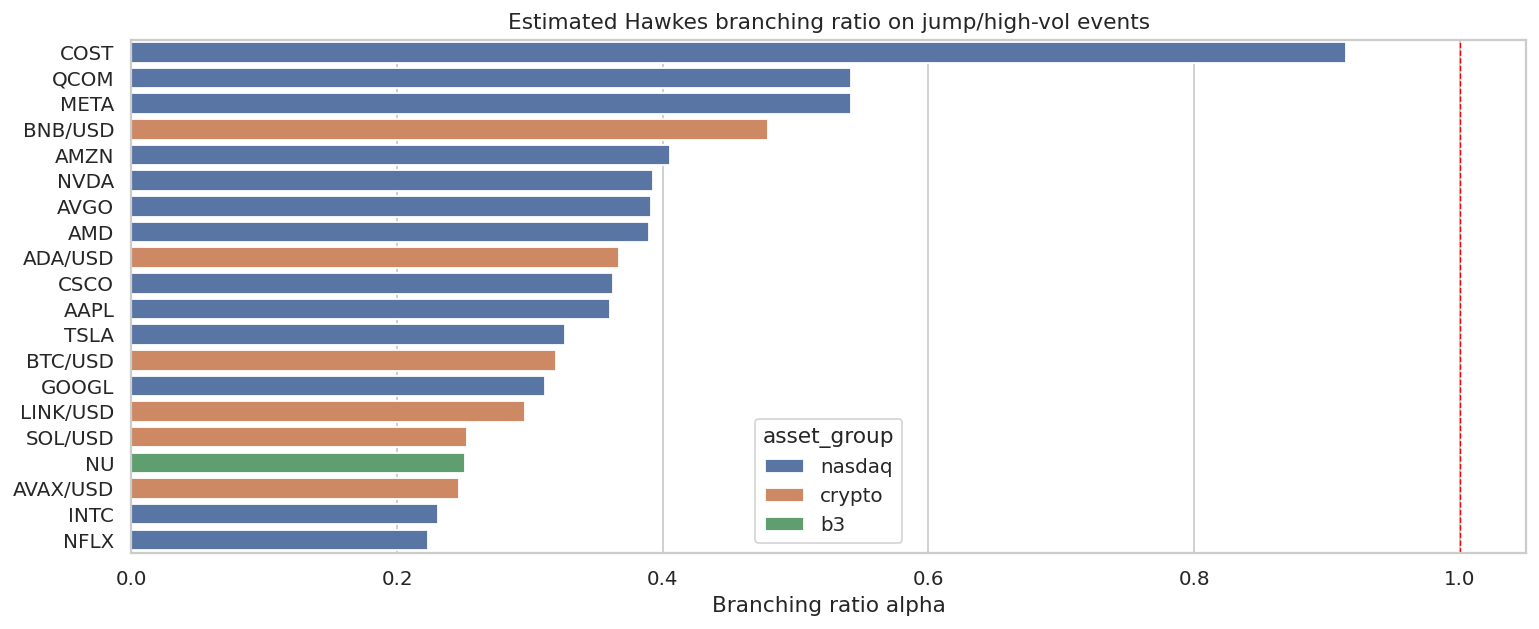

Saved: images/volatility_regime_analysis/hawkes_branching_ratio.png


In [8]:
hawkes_summary, hawkes_intensity = fit_hawkes_for_symbols(indicators, cfg)
print(f"Hawkes summary rows: {len(hawkes_summary):,}")
print(f"Hawkes intensity rows: {len(hawkes_intensity):,}")
display(hawkes_summary.head(20))

fig, ax = plt.subplots(figsize=(12, 5))
plot_h = hawkes_summary.dropna(subset=['branching_ratio']).head(20)
sns.barplot(data=plot_h, y='symbol', x='branching_ratio', hue='asset_group', dodge=False, ax=ax)
ax.axvline(1, color='red', ls='--', lw=0.8)
ax.set_title('Estimated Hawkes branching ratio on jump/high-vol events')
ax.set_xlabel('Branching ratio alpha')
ax.set_ylabel('')
fig.tight_layout()
hawkes_summary_path = fig_dir / 'hawkes_branching_ratio.png'
fig.savefig(hawkes_summary_path, dpi=160, bbox_inches='tight')
plt.show()
print(f"Saved: {hawkes_summary_path}")

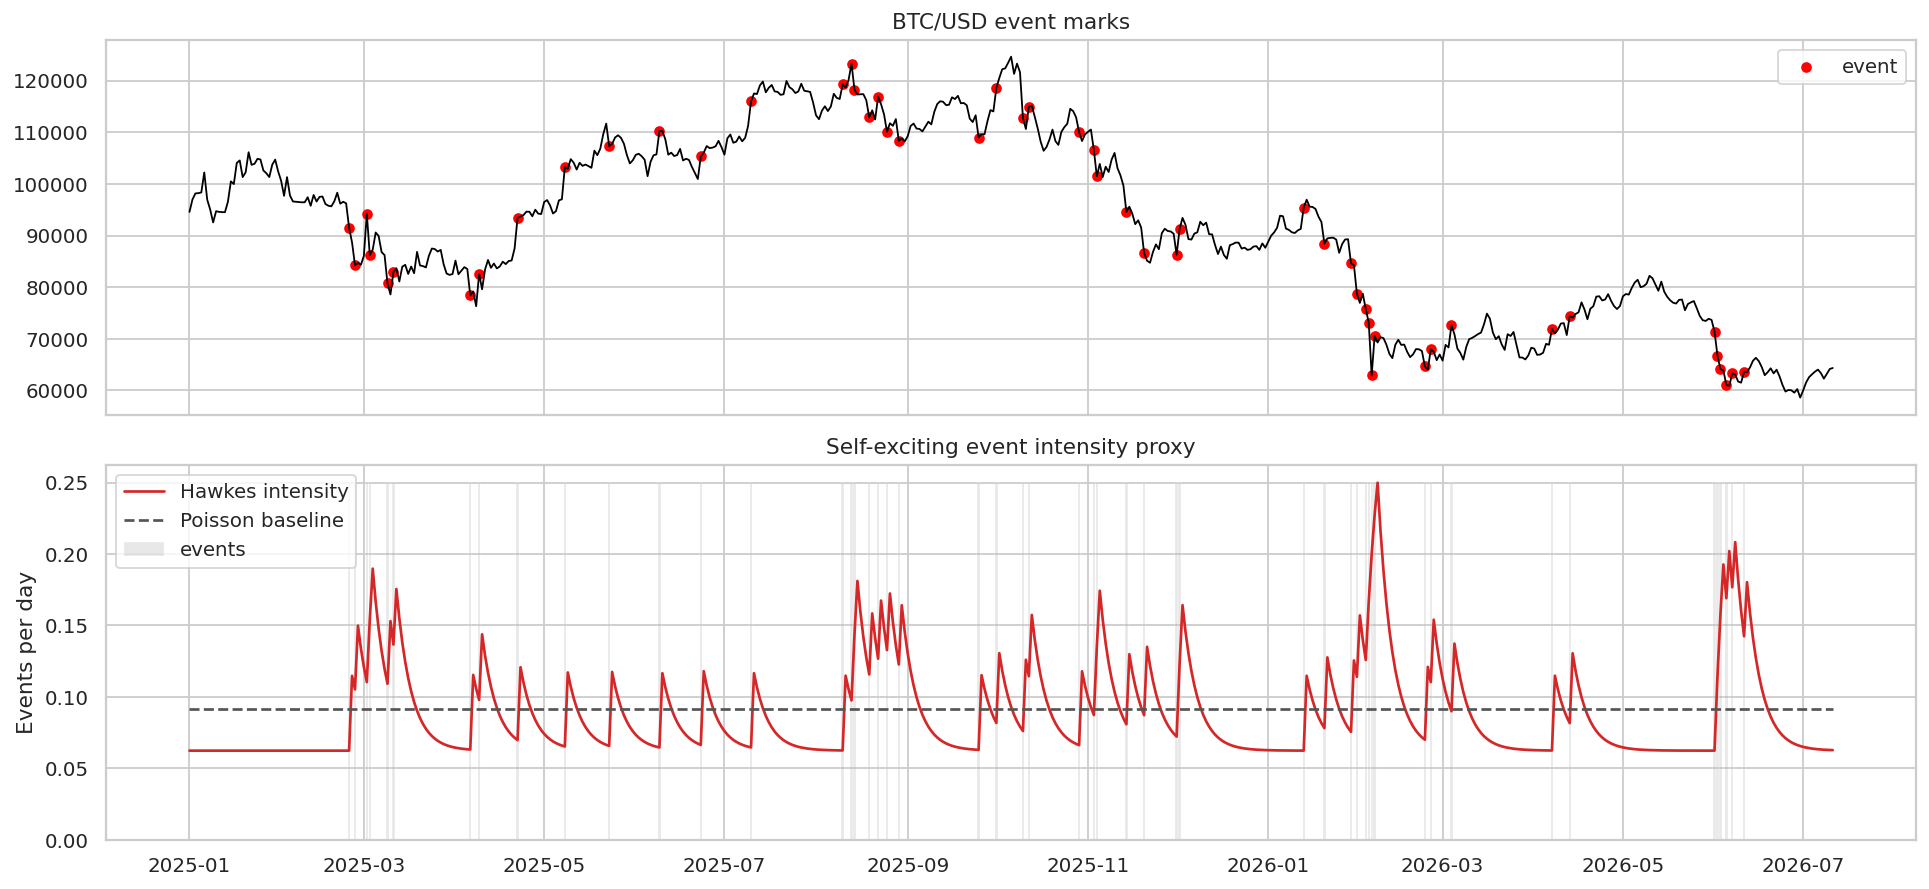

Saved: images/volatility_regime_analysis/BTC-USD_hawkes_intensity.png


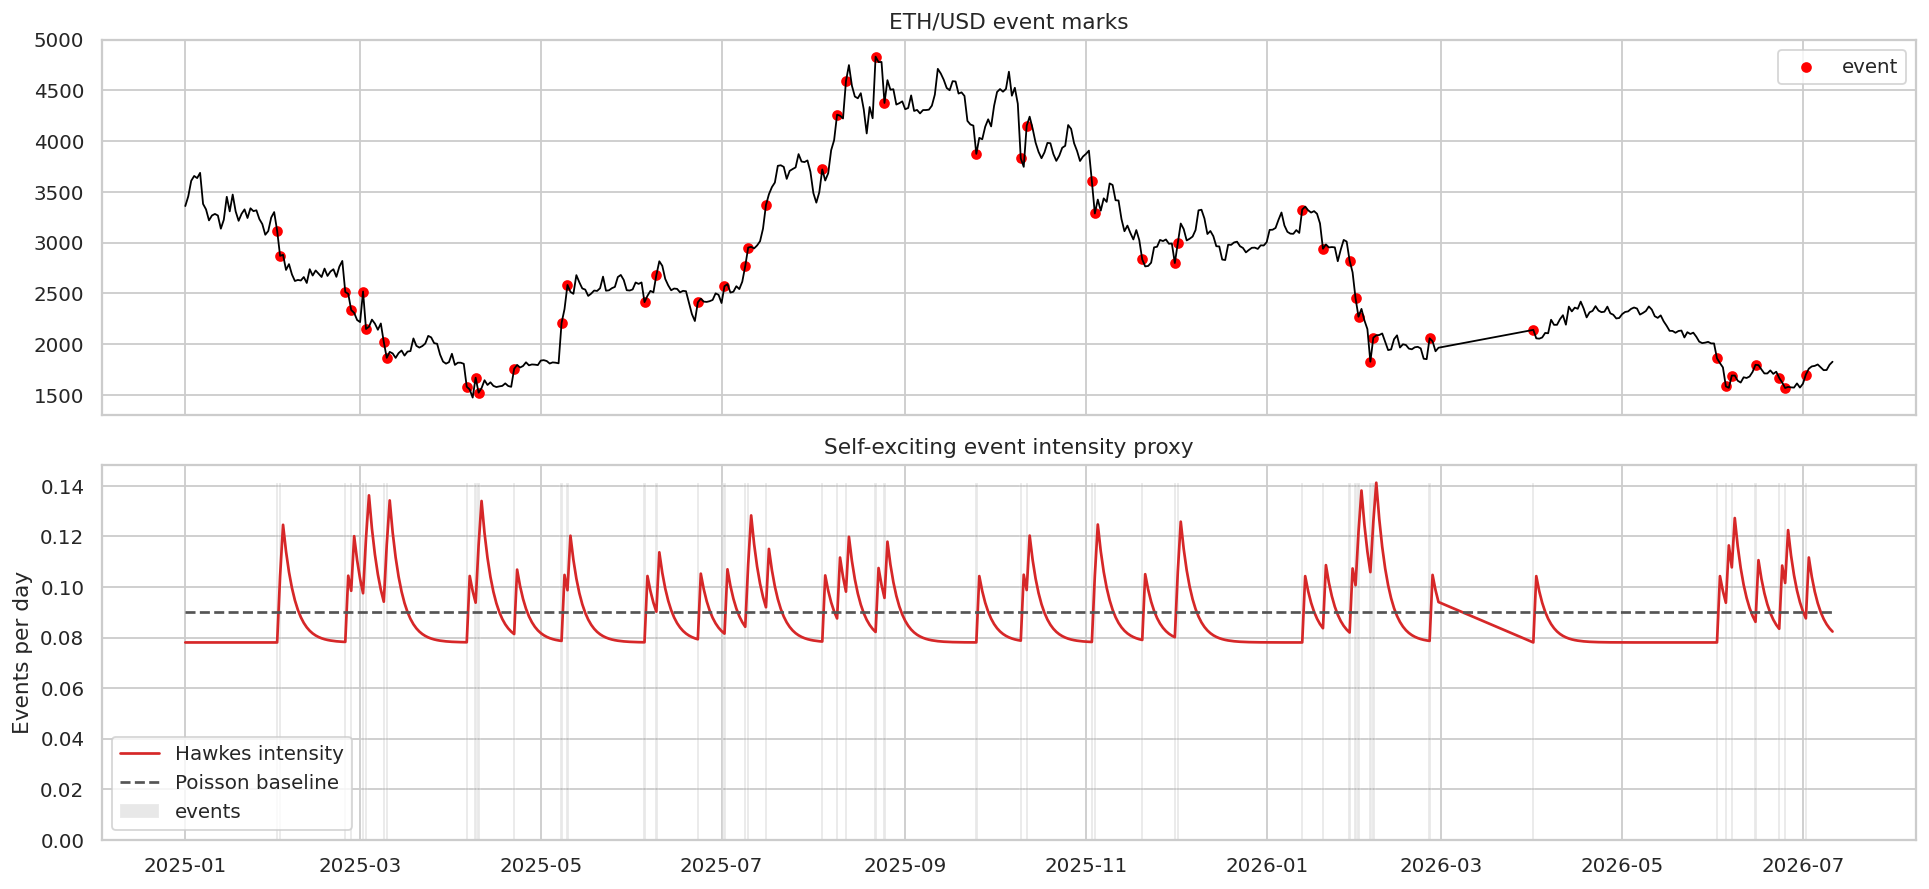

Saved: images/volatility_regime_analysis/ETH-USD_hawkes_intensity.png


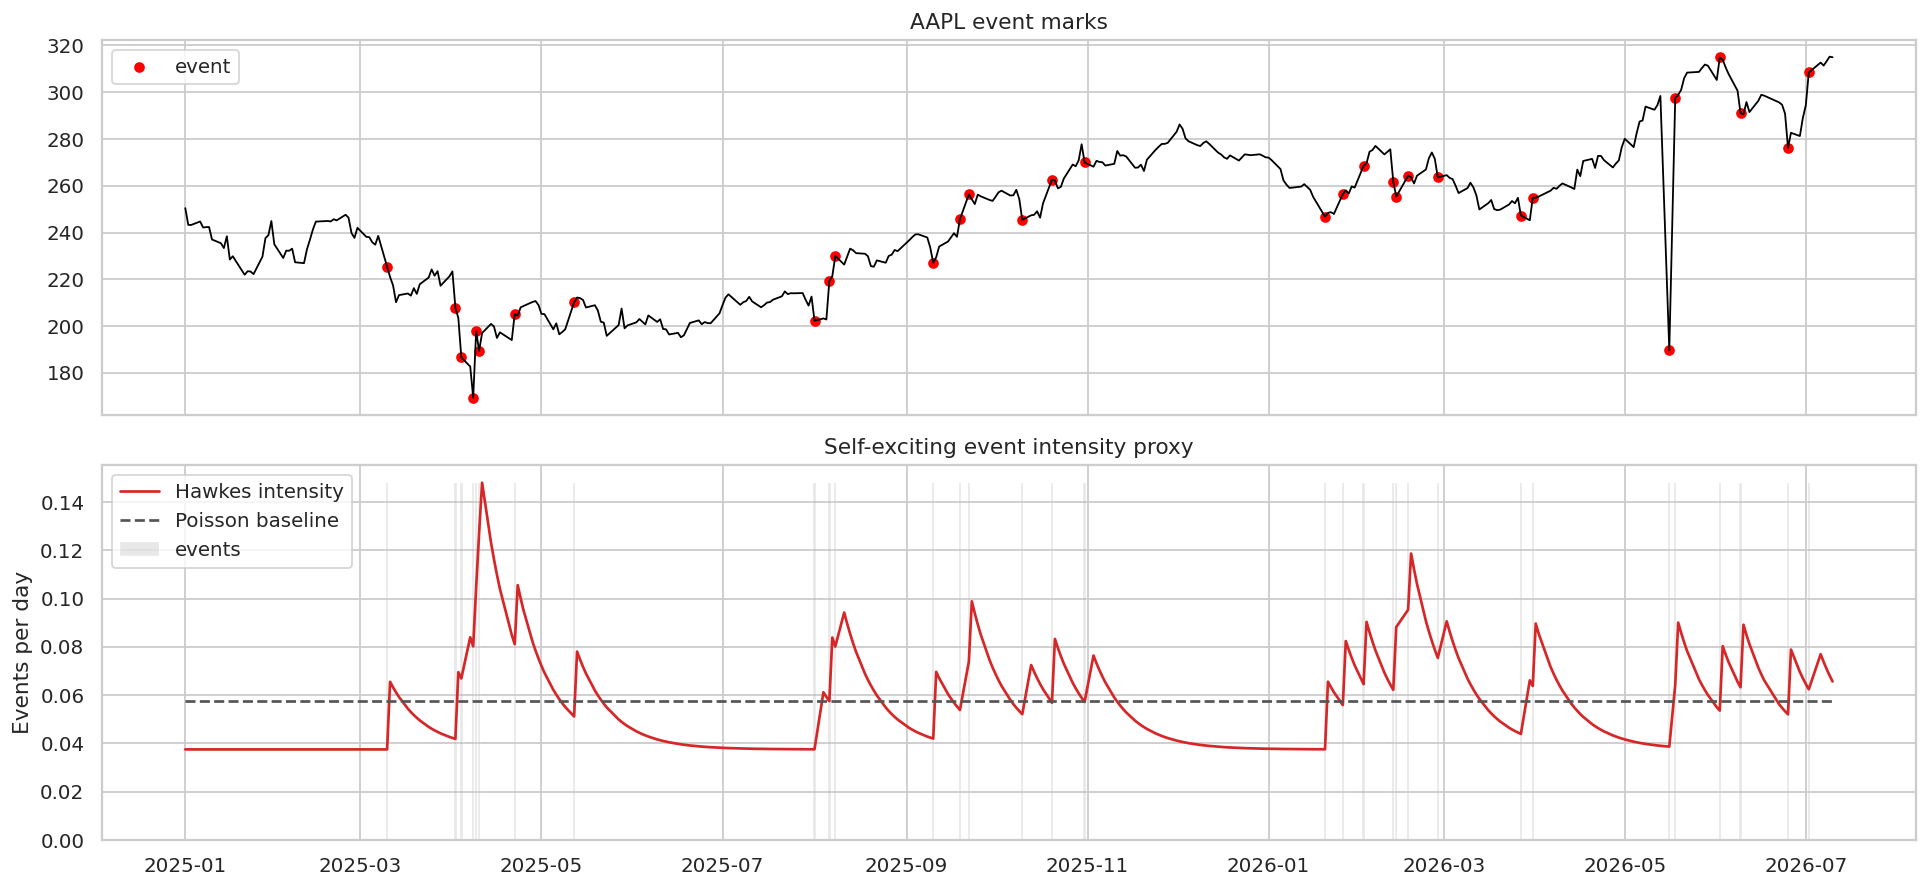

Saved: images/volatility_regime_analysis/AAPL_hawkes_intensity.png


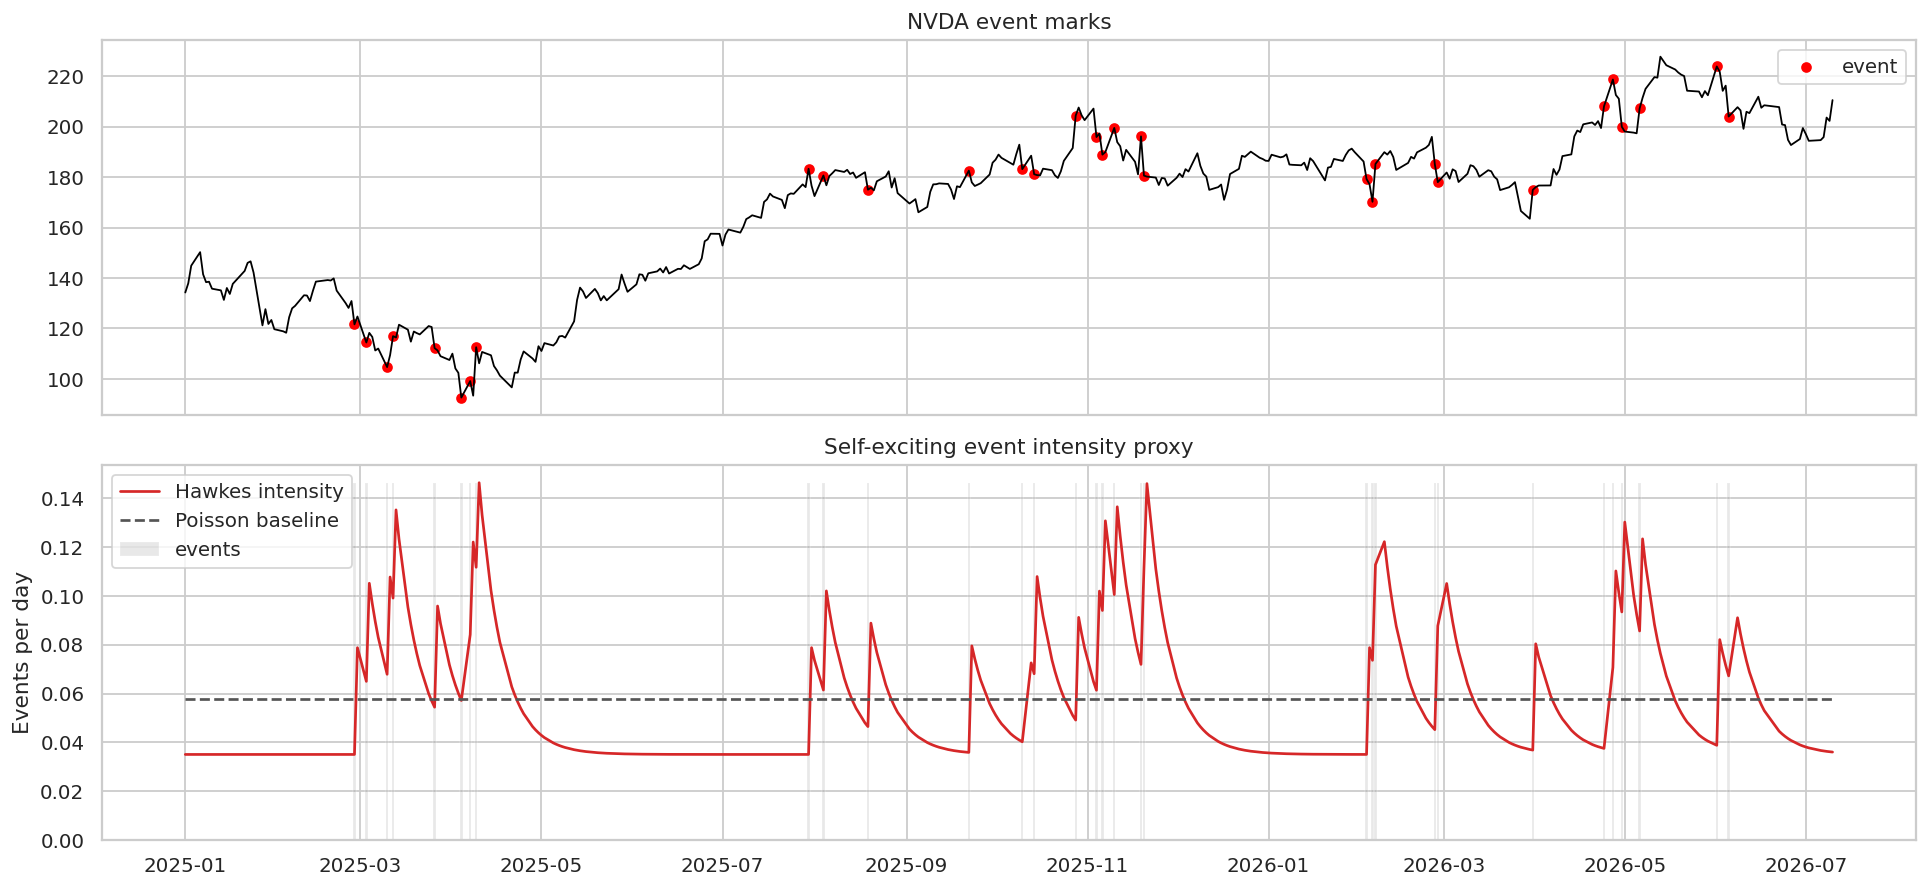

Saved: images/volatility_regime_analysis/NVDA_hawkes_intensity.png


In [9]:
def plot_hawkes_symbol(symbol: str):
    hi = hawkes_intensity[hawkes_intensity['symbol'] == symbol].sort_values('timestamp')
    px = indicators[indicators['symbol'] == symbol][['timestamp', 'close']].sort_values('timestamp')
    if hi.empty or px.empty:
        print(f"No Hawkes output for {symbol}")
        return None
    data = hi.merge(px, on='timestamp', how='left')
    fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
    axes[0].plot(data['timestamp'], data['close'], color='black', lw=1)
    events = data[data['event_flag'] == 1]
    axes[0].scatter(events['timestamp'], events['close'], color='red', s=24, label='event')
    axes[0].set_title(f'{symbol} event marks')
    axes[0].legend(loc='best')

    axes[1].plot(data['timestamp'], data['hawkes_intensity'], color='#d62728', label='Hawkes intensity')
    axes[1].plot(data['timestamp'], data['poisson_intensity'], color='#555555', ls='--', label='Poisson baseline')
    axes[1].bar(data['timestamp'], data['event_flag'] * data['hawkes_intensity'].max(), color='gray', alpha=0.18, label='events')
    axes[1].set_title('Self-exciting event intensity proxy')
    axes[1].set_ylabel('Events per day')
    axes[1].legend(loc='best')
    fig.tight_layout()
    path = fig_dir / f'{symbol.replace("/", "-")}_hawkes_intensity.png'
    fig.savefig(path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")
    return path

for symbol in cfg.selected_symbols[:4]:
    plot_hawkes_symbol(symbol)

In [10]:
options_raw = fetch_lse_options(cfg.option_underlyings, cfg)
option_indicators = summarize_option_indicators(options_raw, indicators)
print(f"Raw option rows: {len(options_raw):,}")
print(f"Option indicator rows: {len(option_indicators):,}")
if options_raw.empty:
    print("No option rows fetched. Check LSE_API_KEY and underlyings.")
else:
    display(options_raw.head())
    display(option_indicators)

Raw option rows: 7,724
Option indicator rows: 5


,ticker,underlying,strike,expiry,contract_type,last_price,volume_today,premium_today,underlying_price,dte,iv,delta,gamma,theta,vega,rho,last_trade_at,updated_at,requested_underlying,moneyness
0,AAPL260702P00120000,AAPL,120.0,2026-07-02 00:00:00+00:00,put,0.01,1000,1000.0,295.36,8,1.9071,-0.0004,0.000018,-0.0080,0.0007,-0.0000,2026-06-24 19:04:34.201239+00:00,2026-06-24 19:04:50.743158+00:00,AAPL,0.406284
1,AAPL260702P00130000,AAPL,130.0,2026-07-02 00:00:00+00:00,put,0.01,2,2.0,291.07,20,1.0877,-0.0005,0.000023,-0.0032,0.0012,-0.0001,2026-06-12 17:42:16.488461+00:00,2026-06-12 17:42:42.388425+00:00,AAPL,0.446628
2,AAPL260702P00140000,AAPL,140.0,2026-07-02 00:00:00+00:00,put,0.17,1,17.0,299.92,10,1.9135,-0.0051,0.000156,-0.0700,0.0073,-0.0005,2026-06-22 17:00:30.245135+00:00,2026-06-22 17:00:43.551622+00:00,AAPL,0.466791
3,AAPL260702P00180000,AAPL,180.0,2026-07-02 00:00:00+00:00,put,0.02,40,80.0,291.96,20,0.7134,-0.0014,0.000093,-0.0055,0.0031,-0.0002,2026-06-12 15:44:07.364370+00:00,2026-06-12 15:44:24.286966+00:00,AAPL,0.616523
4,AAPL260702C00235000,AAPL,235.0,2026-07-02 00:00:00+00:00,call,65.27,1,6527.0,299.81,10,0.7099,0.9837,0.001145,-0.0953,0.0200,0.0629,2026-06-22 17:27:27.019411+00:00,2026-06-22 17:27:31.008339+00:00,AAPL,0.783830


,underlying,contracts,expiries,underlying_price,atm_iv,mean_iv,median_iv,iv_dispersion,term_slope_far_minus_near,put_downside_minus_call_upside_skew,net_gamma_volume_proxy,vega_volume_proxy,min_dte,max_dte,updated_at,rv_close_20,rv_yang_zhang_20,rv_timestamp,iv_minus_rv20,iv_minus_yz20
0,AAPL,1301,19,314.790,0.2061,0.482858,0.34220,0.377695,0.0468,0.072712,3004.464985,64147.6570,7.0,179.0,2026-07-10 20:00:39.470115+00:00,0.316828,0.301960,2026-07-10 00:00:00+00:00,-0.110728,-0.095860
1,MSFT,1617,19,385.020,0.4045,0.461700,0.42620,0.145772,0.0554,0.005576,1249.880532,64953.0993,7.0,178.0,2026-07-10 20:00:39.470115+00:00,0.358952,0.362350,2026-07-10 00:00:00+00:00,0.045548,0.042150
2,NVDA,1728,19,209.880,0.4368,0.709963,0.51690,0.530060,-0.1045,0.060200,16022.080366,215267.2940,7.0,179.0,2026-07-10 20:00:39.470115+00:00,0.366673,0.374246,2026-07-10 00:00:00+00:00,0.070127,0.062554
3,TSLA,2640,18,408.060,0.4237,0.770648,0.57385,0.497960,0.0452,0.025933,1592.025372,95945.1438,7.0,179.0,2026-07-10 20:00:39.470115+00:00,0.587188,0.529673,2026-07-10 00:00:00+00:00,-0.163488,-0.105973
4,VALE,228,11,14.525,0.2889,0.678821,0.43190,0.702063,-0.2247,0.107714,5722.751787,338.8258,7.0,179.0,2026-07-10 20:00:09.265102+00:00,0.308541,0.322876,2026-07-10 00:00:00+00:00,-0.019641,-0.033976


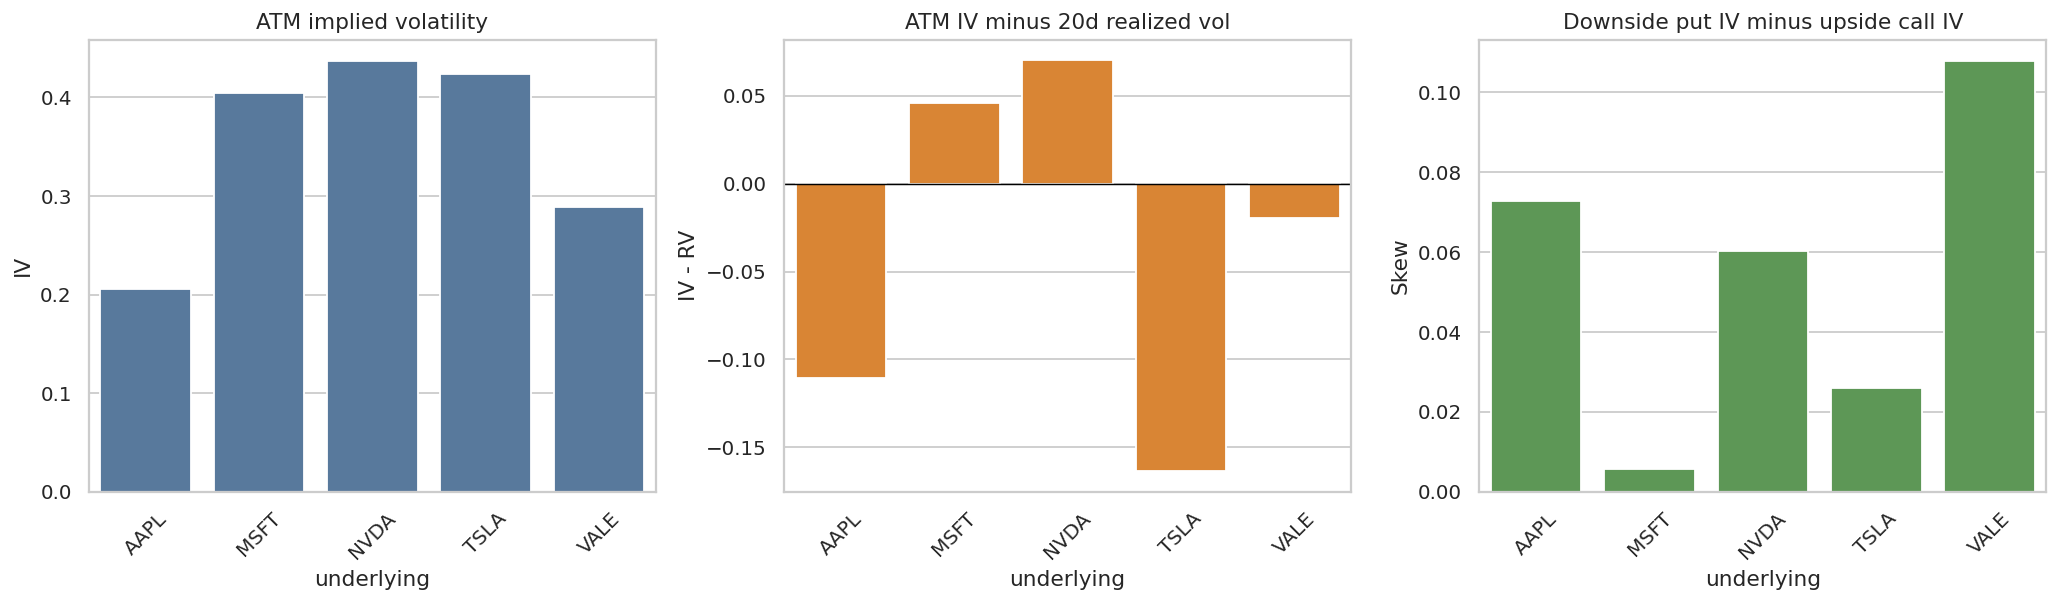

Saved: images/volatility_regime_analysis/option_iv_indicators.png


In [11]:
if not option_indicators.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    sns.barplot(data=option_indicators, x='underlying', y='atm_iv', ax=axes[0], color='#4c78a8')
    axes[0].set_title('ATM implied volatility')
    axes[0].set_ylabel('IV')
    axes[0].tick_params(axis='x', rotation=45)

    sns.barplot(data=option_indicators, x='underlying', y='iv_minus_rv20', ax=axes[1], color='#f58518')
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('ATM IV minus 20d realized vol')
    axes[1].set_ylabel('IV - RV')
    axes[1].tick_params(axis='x', rotation=45)

    sns.barplot(data=option_indicators, x='underlying', y='put_downside_minus_call_upside_skew', ax=axes[2], color='#54a24b')
    axes[2].axhline(0, color='black', lw=0.8)
    axes[2].set_title('Downside put IV minus upside call IV')
    axes[2].set_ylabel('Skew')
    axes[2].tick_params(axis='x', rotation=45)
    fig.tight_layout()
    option_path = fig_dir / 'option_iv_indicators.png'
    fig.savefig(option_path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f"Saved: {option_path}")
else:
    print("Option plot skipped: no option indicators available.")

In [12]:
paths = save_outputs(
    cfg,
    indicators,
    hmm_regimes,
    hmm_summary,
    hawkes_summary,
    hawkes_intensity,
    option_indicators,
    options_raw,
)

for name, path in paths.items():
    print(f"{name}: {path}")

print("Notebook complete")

indicators: data/volatility_regime_analysis/market_indicators.parquet
hmm_regimes: data/volatility_regime_analysis/hmm_regimes.parquet
hmm_summary: data/volatility_regime_analysis/hmm_summary.csv
hawkes_summary: data/volatility_regime_analysis/hawkes_summary.csv
hawkes_intensity: data/volatility_regime_analysis/hawkes_intensity.parquet
option_indicators: data/volatility_regime_analysis/option_iv_indicators.csv
options_raw: data/volatility_regime_analysis/lse_options_raw.parquet
Notebook complete
